In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go



In [31]:
funds = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/raw/02_nav_history.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    # annotation_text="Bull Run",
    fillcolor="green",
    opacity=0.15
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="Market Correction",
    fillcolor="red",
    opacity=0.15
)

fig.show()
fig.write_html("../reports/nav_trend.html")

Text(0.5, 1.0, 'AUM Growth by Fund House')

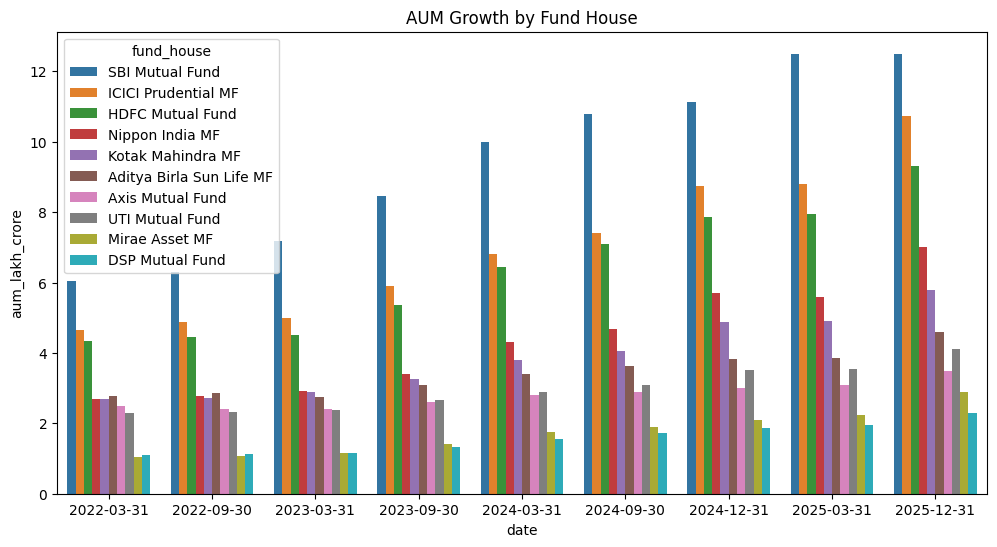

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")



In [ ]:
fig1 = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

fig1.add_annotation(
    x="2025-12",
    y=31002,
    text="₹31,002 Cr ATH"
)

fig1.show()

Text(0.5, 1.0, 'Category Inflows Heatmap')

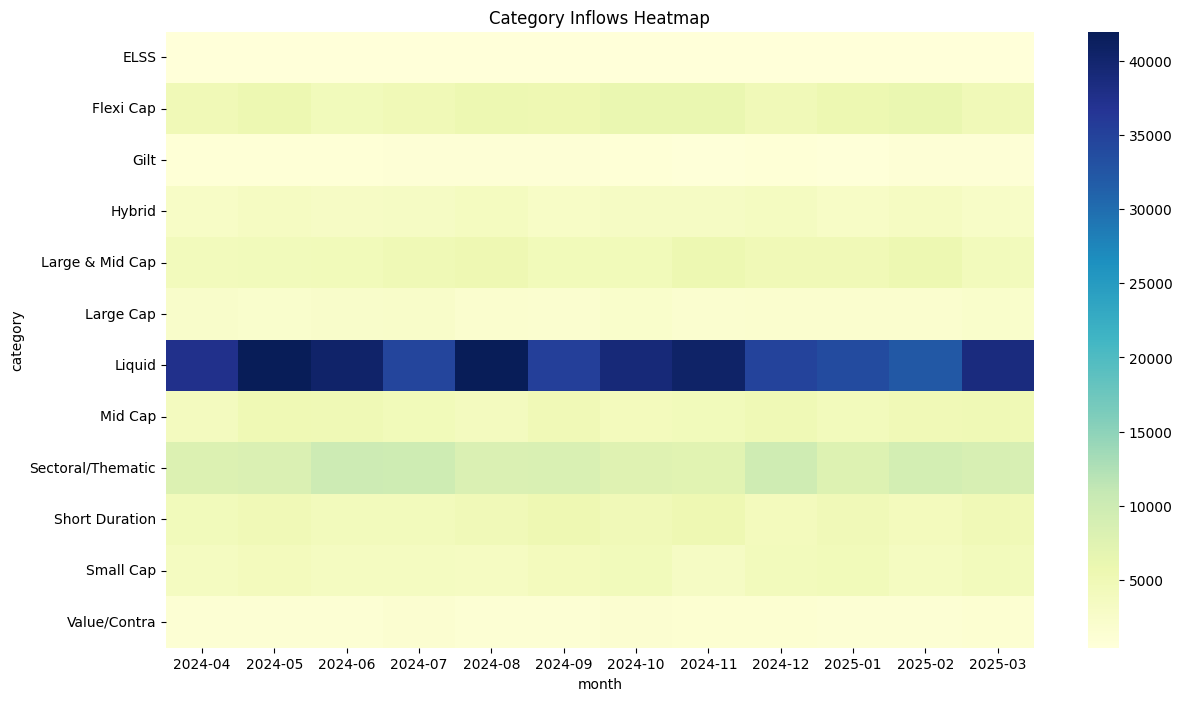

In [14]:
pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title(
    "Category Inflows Heatmap"
)



Text(0.5, 1.0, 'Investor Age Distribution')

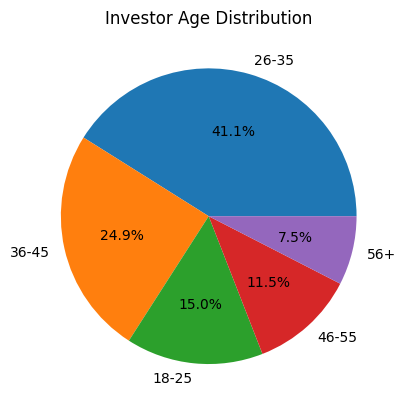

In [16]:
age = (
    transactions["age_group"]
    .value_counts()
)

plt.pie(
    age,
    labels=age.index,
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Distribution"
)


Text(0.5, 1.0, 'SIP Amount by Age Group')

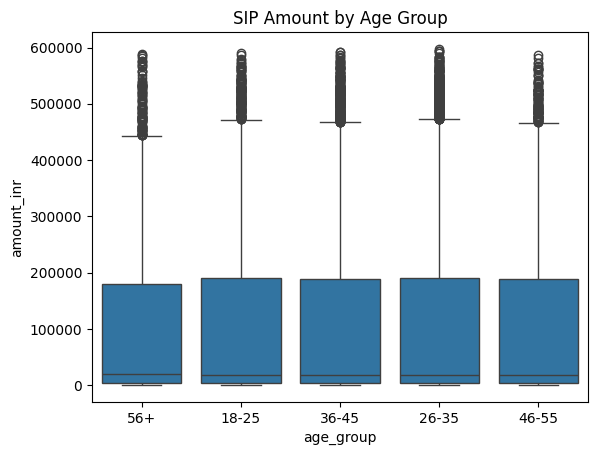

In [18]:
# investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount by Age Group"
)

Text(0.5, 1.0, 'Gender Distribution')

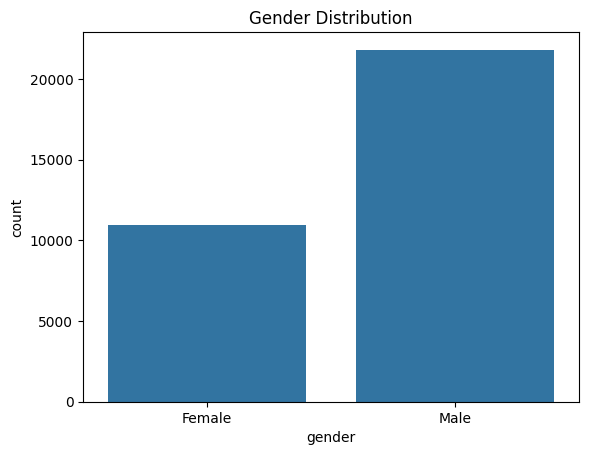

In [19]:
sns.countplot(
    data=transactions,
    x="gender"
)

plt.title(
    "Gender Distribution"
)

Text(0.5, 1.0, 'State-wise SIP Contribution')

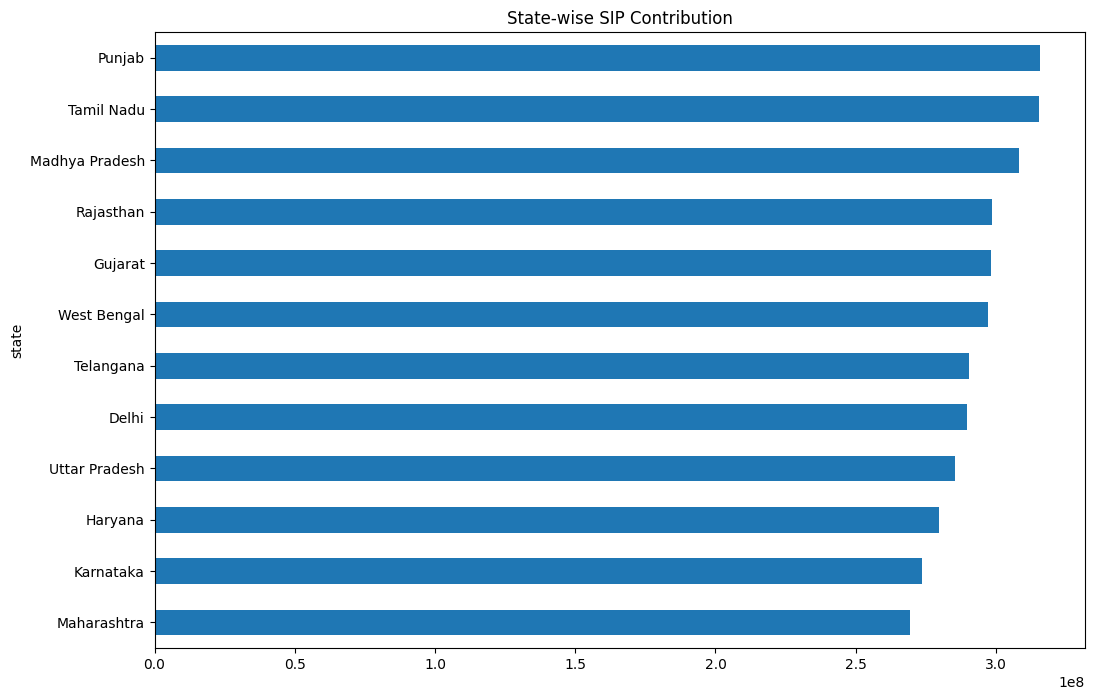

In [22]:
state = (
    transactions.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values()
)

state.plot(
    kind="barh",
    figsize=(12,8)
)

plt.title(
    "State-wise SIP Contribution"
)


Text(0.5, 1.0, 'T30 vs B30 Investors')

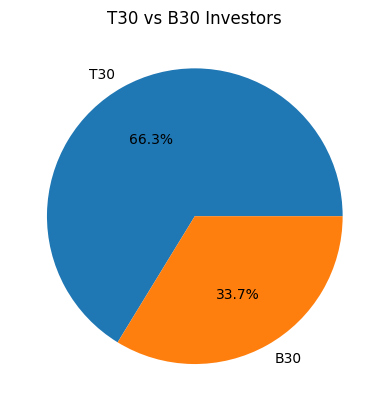

In [23]:
tier = (
    transactions["city_tier"]
    .value_counts()
)

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 Investors"
)

In [27]:
# amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date

fig = px.line(
    portfolio,
    x="portfolio_date",
    y="amfi_code"
)

fig.add_annotation(
    x="2022-01",
    y=13.26,
    text="13.26 Cr"
)

fig.add_annotation(
    x="2025-12",
    y=26.12,
    text="26.12 Cr"
)

fig.show()

Text(0.5, 1.0, 'Sector Allocation')

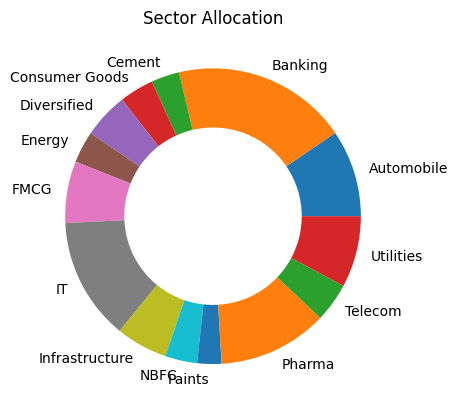

In [33]:
#  amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
sector = (
    portfolio.groupby("sector")["weight_pct"].sum()
)

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops=dict(width=0.4)
)

plt.title(
    "Sector Allocation"
)


10 EDA Findings

1. SBI Mutual Fund remained the largest AMC with AUM exceeding ₹12.5 lakh crore.

2. Industry SIP inflows reached an all-time high of ₹31,002 crore in December 2025.

3. Equity categories attracted the highest net inflows across the study period.

4. The 25–35 age group represented the largest investor segment.

5. T30 cities contributed the majority of SIP investments.

6. Portfolio counts nearly doubled from 13.26 crore to 26.12 crore.

7. Large-cap funds exhibited strong positive correlation.

8. Technology and Financial Services dominated sector allocations.

9. Expense ratios remained within regulatory norms for most schemes.

10. NAV growth accelerated during the 2023 bull market and moderated during 2024 corrections.